## 의사결정 트리와 랜덤 포레스트 학습 목표에 따른 코딩 시나리오

제공해주신 학습 목표를 바탕으로 각 목표에 해당하는 개념을 파이썬 `scikit-learn` 라이브러리를 사용하여 코드로 구현하고 설명합니다.

### **학습 목표 01: 트리를 읽고 만든다**

의사결정 트리의 기본 구조(루트, 내부 노드, 잎 노드, 깊이)를 이해하고, 데이터를 분할하는 과정에서 불순도(지니 불순도, 정보 이득)를 최소화하는 분할 기준을 찾는 과정을 시각적으로 보여줍니다.

의사결정 트리 모델 학습 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

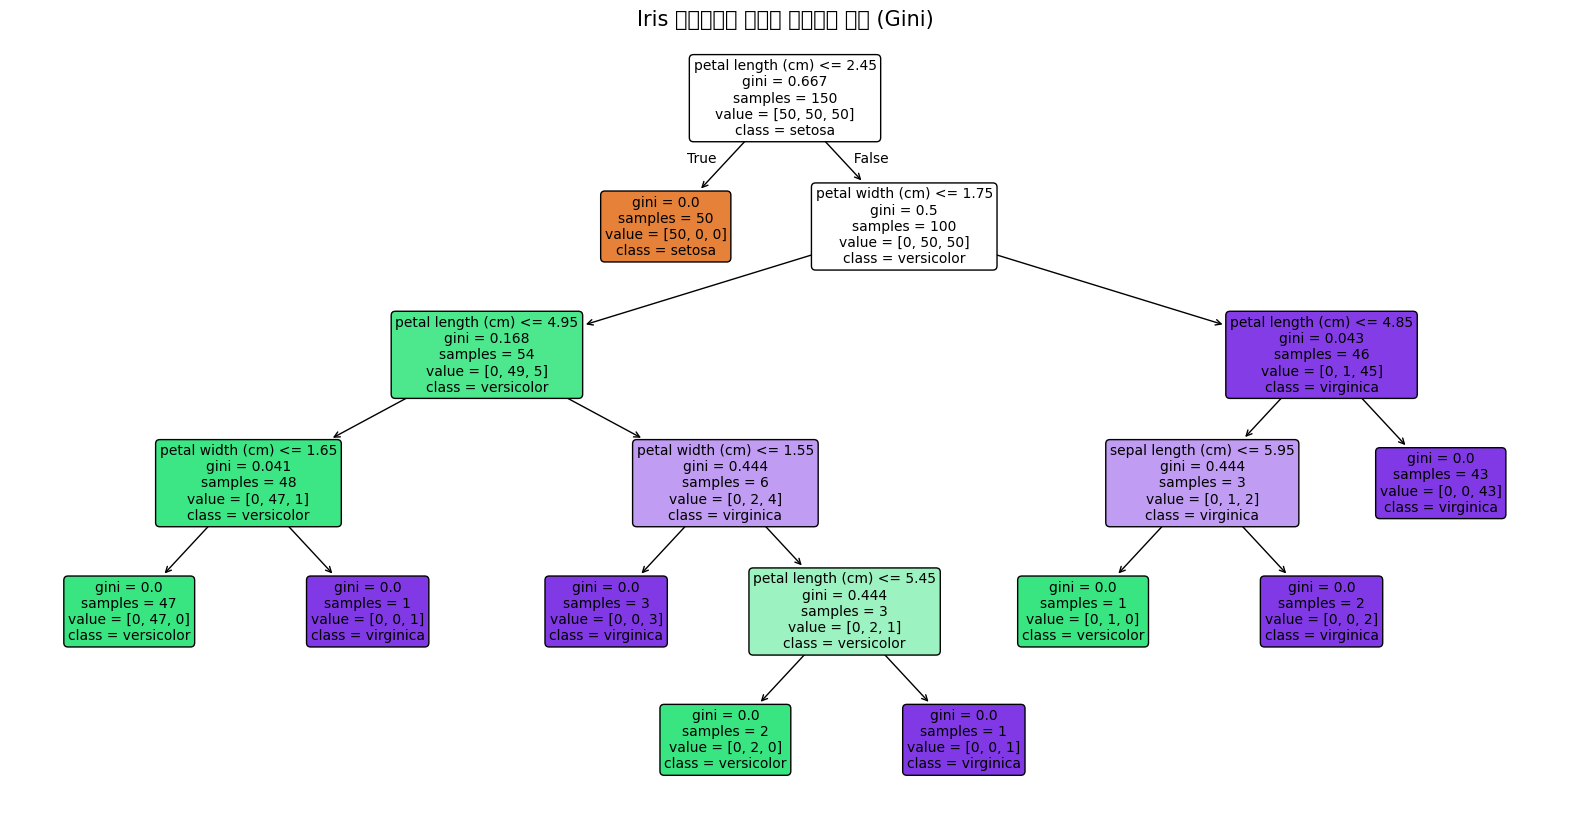


--- Gini 불순도 설명 ---
Gini 불순도는 노드의 순수도를 측정하는 지표입니다. 0에 가까울수록 노드가 순수하다고(하나의 클래스로만 구성) 볼 수 있습니다. 의사결정 트리는 이 Gini 불순도를 가장 크게 감소시키는 방향으로 데이터를 분할합니다. 불순도 감소량이 클수록 해당 분할이 더 중요하다고 판단합니다.

**Gini 불순도 계산 예시:**
어떤 노드에 2개의 클래스(A, B)가 있고, 총 10개의 샘플 중 A가 7개, B가 3개 있다고 가정해봅시다.
Gini = 1 - ( (클래스 A 비율)^2 + (클래스 B 비율)^2 )
Gini = 1 - ( (7/10)^2 + (3/10)^2 ) = 1 - (0.49 + 0.09) = 1 - 0.58 = 0.42
이 노드의 Gini 불순도는 0.42입니다. 불순도(Gini)가 낮을수록 노드의 순도가 높습니다.


In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Iris 데이터셋 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 의사결정 트리 모델 생성 및 학습 (Gini 불순도 사용)
tree_classifier = DecisionTreeClassifier(random_state=42)
tree_classifier.fit(X, y)

print("의사결정 트리 모델 학습 완료!")

# 트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(tree_classifier,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Iris 데이터셋을 활용한 의사결정 트리 (Gini)", fontsize=15)
plt.show()

print("\n--- Gini 불순도 설명 ---")
print("Gini 불순도는 노드의 순수도를 측정하는 지표입니다. 0에 가까울수록 노드가 순수하다고(하나의 클래스로만 구성) 볼 수 있습니다. 의사결정 트리는 이 Gini 불순도를 가장 크게 감소시키는 방향으로 데이터를 분할합니다. 불순도 감소량이 클수록 해당 분할이 더 중요하다고 판단합니다.\n")
print("**Gini 불순도 계산 예시:**\n어떤 노드에 2개의 클래스(A, B)가 있고, 총 10개의 샘플 중 A가 7개, B가 3개 있다고 가정해봅시다.\nGini = 1 - ( (클래스 A 비율)^2 + (클래스 B 비율)^2 )\nGini = 1 - ( (7/10)^2 + (3/10)^2 ) = 1 - (0.49 + 0.09) = 1 - 0.58 = 0.42\n이 노드의 Gini 불순도는 0.42입니다. 불순도(Gini)가 낮을수록 노드의 순도가 높습니다.")


In [16]:
from collections import Counter
import numpy as np

def calculate_gini_impurity(labels):
    # 클래스 레이블의 빈도 계산
    counts = Counter(labels)
    num_samples = sum(counts.values())

    if num_samples == 0:
        return 0.0

    gini = 1.0
    for label in counts:
        probability = counts[label] / num_samples
        gini -= probability**2
    return gini

print("--- Gini 불순도 계산 함수 예시 ---")

# 예시 1: 두 개의 클래스(A, B)가 있고, 총 10개의 샘플 중 A가 7개, B가 3개인 경우
example_labels_1 = ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B']
gini_1 = calculate_gini_impurity(example_labels_1)
print(f"예시 1 (A:7, B:3) Gini 불순도: {gini_1:.4f}")

# 예시 2: 클래스가 모두 동일하여 완벽하게 순수한 노드 (Gini = 0)
example_labels_2 = ['A', 'A', 'A', 'A', 'A']
gini_2 = calculate_gini_impurity(example_labels_2)
print(f"예시 2 (모두 A) Gini 불순도: {gini_2:.4f}")

# 예시 3: 클래스가 균등하게 분포하여 가장 불순한 노드 (두 클래스인 경우 Gini = 0.5)
example_labels_3 = ['A', 'A', 'A', 'B', 'B', 'B']
gini_3 = calculate_gini_impurity(example_labels_3)
print(f"예시 3 (A:3, B:3) Gini 불순도: {gini_3:.4f}")

# 예시 4: Iris 데이터셋 첫 번째 분할 (Gini = 0.667)에 대한 근사치 검증
# 여기서는 간략하게 클래스 분포만 고려하여 계산합니다.
# 전체 Iris 데이터셋 (150개 샘플)에서 각 클래스가 50개씩 있는 경우
# Setosa: 50, Versicolor: 50, Virginica: 50
approx_iris_gini_labels = ['Setosa']*50 + ['Versicolor']*50 + ['Virginica']*50
gini_iris_root = calculate_gini_impurity(approx_iris_gini_labels)
print(f"예시 4 (Iris 루트 노드 근사치) Gini 불순도: {gini_iris_root:.4f}")

print("\n--- Gini 불순도 계산 코드 설명 ---")
print("`calculate_gini_impurity` 함수는 주어진 레이블 리스트를 받아 Gini 불순도를 계산합니다. 각 클래스의 비율을 제곱하여 1에서 빼는 방식으로 노드의 불순도를 측정하며, 0에 가까울수록 순수하고 1에 가까울수록 불순한(최대 불순도는 0.5) 노드임을 의미합니다. 의사결정 트리는 이러한 Gini 불순도가 가장 크게 감소하는 방향으로 분할을 진행합니다.")

--- Gini 불순도 계산 함수 예시 ---
예시 1 (A:7, B:3) Gini 불순도: 0.4200
예시 2 (모두 A) Gini 불순도: 0.0000
예시 3 (A:3, B:3) Gini 불순도: 0.5000
예시 4 (Iris 루트 노드 근사치) Gini 불순도: 0.6667

--- Gini 불순도 계산 코드 설명 ---
`calculate_gini_impurity` 함수는 주어진 레이블 리스트를 받아 Gini 불순도를 계산합니다. 각 클래스의 비율을 제곱하여 1에서 빼는 방식으로 노드의 불순도를 측정하며, 0에 가까울수록 순수하고 1에 가까울수록 불순한(최대 불순도는 0.5) 노드임을 의미합니다. 의사결정 트리는 이러한 Gini 불순도가 가장 크게 감소하는 방향으로 분할을 진행합니다.


### **정보 이득 (Information Gain) 계산 및 설명**

지니 불순도와 함께 의사결정 트리에서 데이터를 분할하는 기준으로 사용되는 또 다른 중요한 개념은 **정보 이득(Information Gain)**입니다. 정보 이득은 특정 특성으로 분할했을 때 데이터셋의 불확실성(엔트로피)이 얼마나 감소하는지를 측정합니다. 엔트로피가 감소할수록 정보 이득은 높아지며, 트리는 정보 이득이 가장 높은 특성을 선택하여 분할합니다.

In [8]:
import numpy as np
from collections import Counter

def entropy(labels):
    # 주어진 레이블 집합에 대한 엔트로피 계산
    n_labels = len(labels)
    if n_labels == 0:
        return 0
    counts = Counter(labels)
    probabilities = [count / n_labels for count in counts.values()]
    return -sum(p * np.log2(p) for p in probabilities if p > 0)

def information_gain(parent_labels, children_labels_list):
    # 정보 이득 계산
    parent_entropy = entropy(parent_labels)
    weighted_children_entropy = sum(
        (len(children_labels) / len(parent_labels)) * entropy(children_labels)
        for children_labels in children_labels_list
    )
    return parent_entropy - weighted_children_entropy

print("--- 정보 이득 계산 예시 ---")

# 간단한 데이터셋 예시: 날씨에 따른 테니스 경기 여부
# Outlook: Sunny, Sunny, Overcast, Rainy, Rainy, Rainy, Overcast, Sunny, Sunny, Rainy, Sunny, Overcast, Overcast, Rainy
# Play: No, No, Yes, Yes, Yes, No, Yes, No, Yes, Yes, Yes, Yes, Yes, No
data = [
    ("Sunny", "No"),
    ("Sunny", "No"),
    ("Overcast", "Yes"),
    ("Rainy", "Yes"),
    ("Rainy", "Yes"),
    ("Rainy", "No"),
    ("Overcast", "Yes"),
    ("Sunny", "No"),
    ("Sunny", "Yes"), # 예시 다양화를 위해 일부 수정
    ("Rainy", "Yes"),
    ("Sunny", "Yes"), # 예시 다양화를 위해 일부 수정
    ("Overcast", "Yes"),
    ("Overcast", "Yes"),
    ("Rainy", "No"),
]

outlooks = [d[0] for d in data]
plays = [d[1] for d in data]

# 전체 데이터셋의 엔트로피 (Play 여부)
total_entropy = entropy(plays)
print(f"전체 엔트로피 (Play): {total_entropy:.4f}")

# 'Outlook' 특성으로 분할했을 때의 정보 이득 계산
# Sunny, Overcast, Rainy로 나누어 자식 노드 그룹 생성
play_sunny = [p for o, p in data if o == "Sunny"] # No, No, No, Yes
play_overcast = [p for o, p in data if o == "Overcast"] # Yes, Yes, Yes, Yes
play_rainy = [p for o, p in data if o == "Rainy"] # Yes, Yes, No, Yes, No

ig_outlook = information_gain(plays, [play_sunny, play_overcast, play_rainy])
print(f"특성 'Outlook'에 대한 정보 이득: {ig_outlook:.4f}")

print("\n--- 정보 이득 설명 ---")
print("정보 이득은 의사결정 트리에서 어떤 특성을 사용하여 데이터를 분할할 때 얻을 수 있는 정보의 양을 측정하는 지표입니다. 부모 노드의 엔트로피(불확실성)와 자식 노드들의 가중 평균 엔트로피의 차이로 계산됩니다.")
print("엔트로피는 데이터셋의 불순도 또는 무질서도를 나타내며, 0에 가까울수록 순수합니다. 정보 이득이 높다는 것은 해당 특성으로 분할했을 때 데이터셋의 불확실성이 크게 감소하여 더 순수한 자식 노드를 만들 수 있음을 의미합니다. 의사결정 트리는 정보 이득을 최대화하는 방향으로 분할 기준을 선택합니다.")

--- 정보 이득 계산 예시 ---
전체 엔트로피 (Play): 0.9403
특성 'Outlook'에 대한 정보 이득: 0.2467

--- 정보 이득 설명 ---
정보 이득은 의사결정 트리에서 어떤 특성을 사용하여 데이터를 분할할 때 얻을 수 있는 정보의 양을 측정하는 지표입니다. 부모 노드의 엔트로피(불확실성)와 자식 노드들의 가중 평균 엔트로피의 차이로 계산됩니다.
엔트로피는 데이터셋의 불순도 또는 무질서도를 나타내며, 0에 가까울수록 순수합니다. 정보 이득이 높다는 것은 해당 특성으로 분할했을 때 데이터셋의 불확실성이 크게 감소하여 더 순수한 자식 노드를 만들 수 있음을 의미합니다. 의사결정 트리는 정보 이득을 최대화하는 방향으로 분할 기준을 선택합니다.


### **학습 목표 02: 과적합을 다스린다**

의사결정 트리가 데이터에 과도하게 맞춰지는(과적합) 경향이 있음을 이해하고, 이를 방지하기 위한 가지치기(Pruning) 기법(예: 최대 깊이 제한, 잎 노드의 최소 샘플 수)을 코드로 구현하여 과적합을 제어하는 방법을 보여줍니다.


과적합된 트리 (깊이 제한 없음) - 훈련 정확도: 1.0000
과적합된 트리 (깊이 제한 없음) - 테스트 정확도: 1.0000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

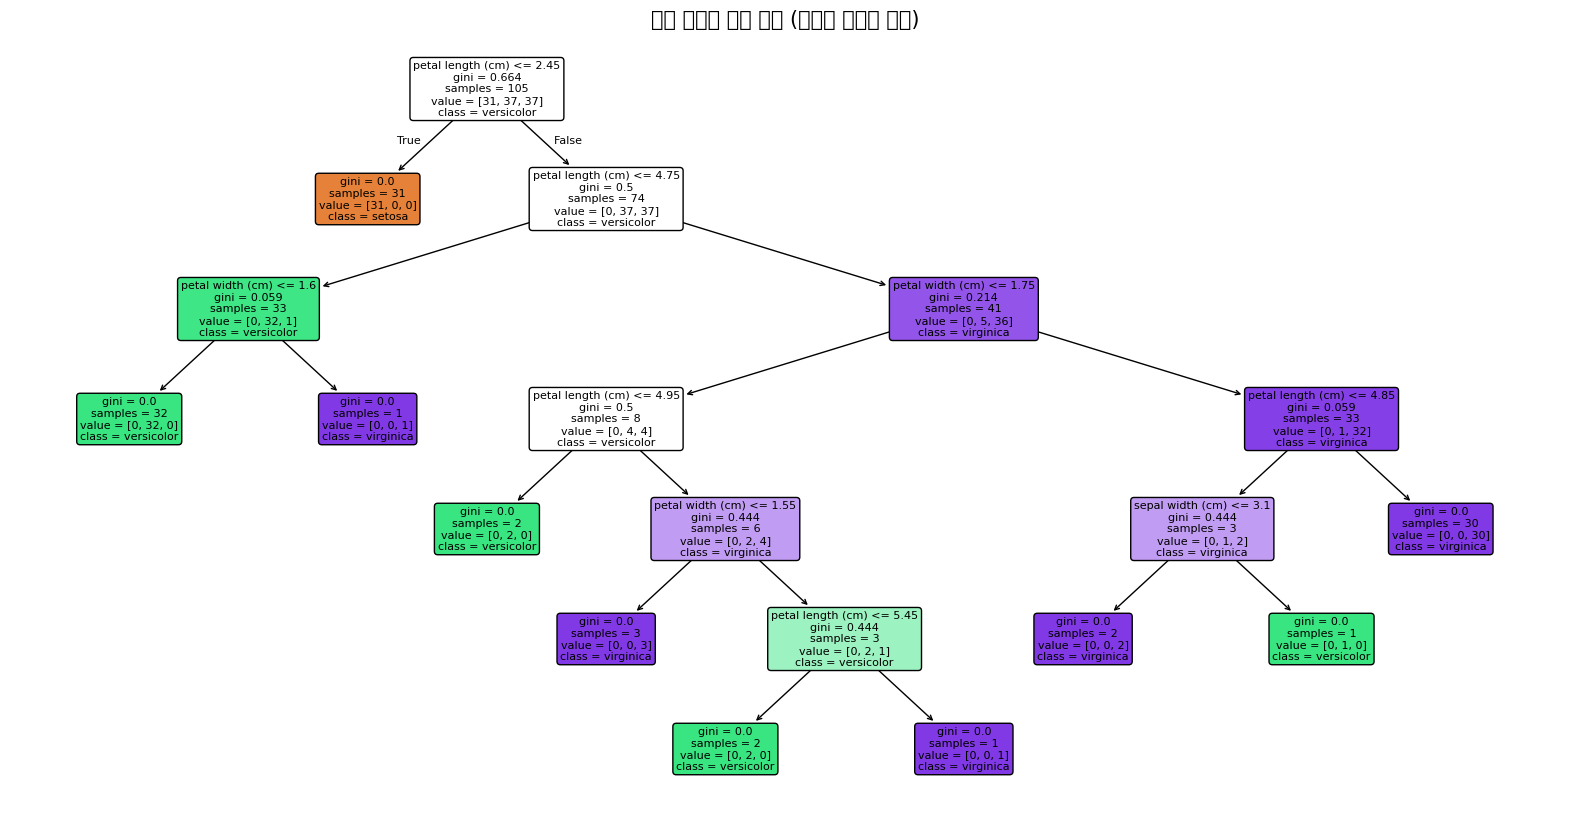


가지치기된 트리 (최대 깊이 3) - 훈련 정확도: 0.9524
가지치기된 트리 (최대 깊이 3) - 테스트 정확도: 1.0000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

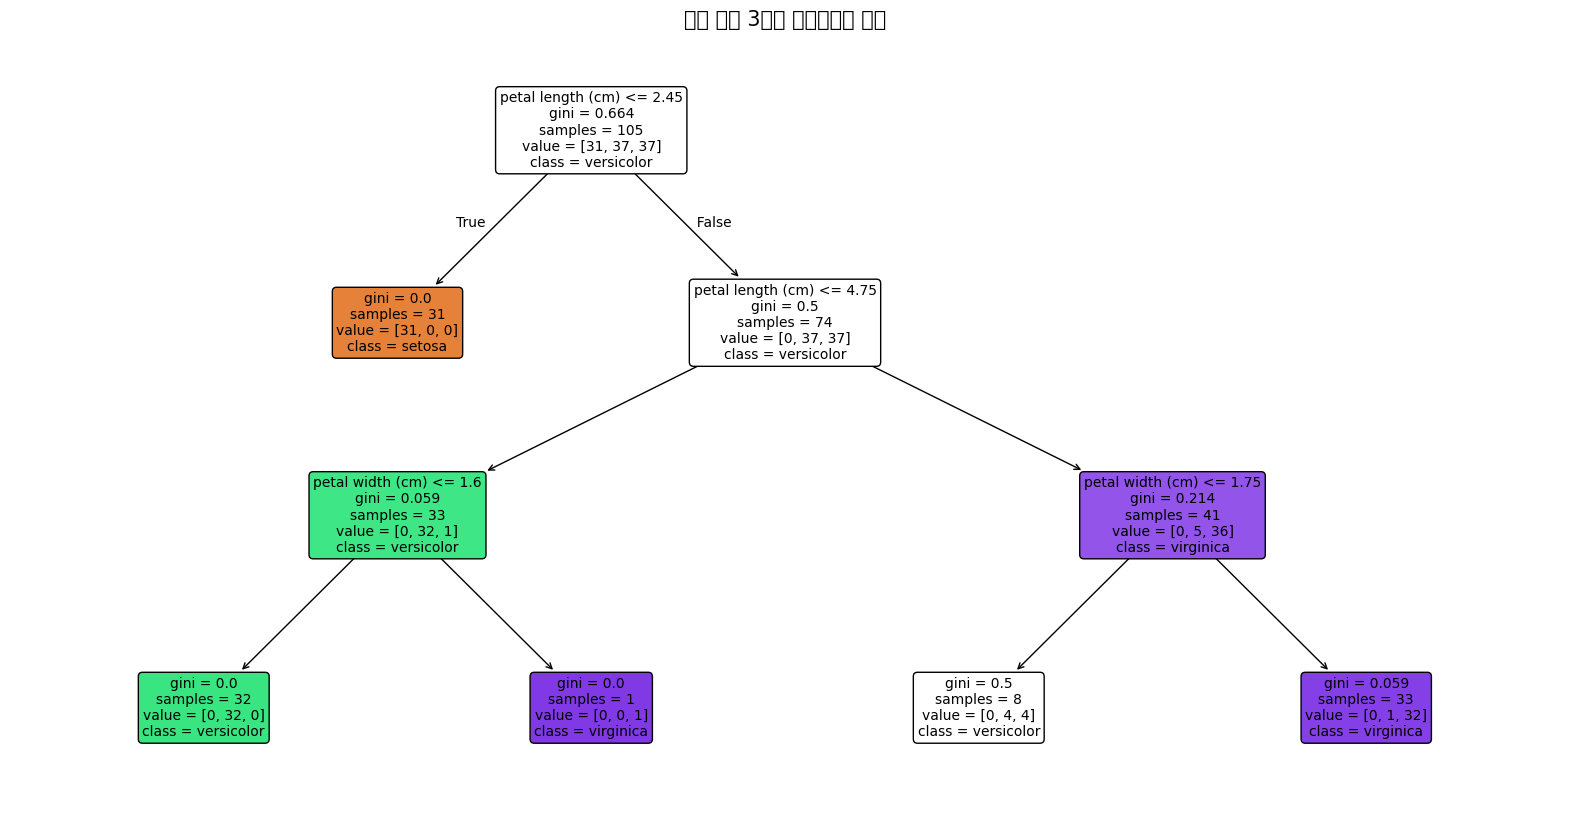


--- 과적합 및 가지치기 설명 ---
깊이 제한이 없는 트리는 훈련 데이터에 완벽하게 맞춰 훈련 정확도가 높을 수 있지만, 새로운 데이터(테스트 데이터)에 대한 성능은 떨어질 수 있습니다 (과적합). `max_depth`와 같은 파라미터로 트리의 깊이를 제한하면, 모델이 훈련 데이터의 노이즈까지 학습하는 것을 방지하여 일반화 성능을 향상시킬 수 있습니다.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터를 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. 과적합된 트리 (깊이 제한 없음)
unpruned_tree = DecisionTreeClassifier(random_state=42)
unpruned_tree.fit(X_train, y_train)

y_train_pred_unpruned = unpruned_tree.predict(X_train)
y_test_pred_unpruned = unpruned_tree.predict(X_test)

print(f"\n과적합된 트리 (깊이 제한 없음) - 훈련 정확도: {accuracy_score(y_train, y_train_pred_unpruned):.4f}")
print(f"과적합된 트리 (깊이 제한 없음) - 테스트 정확도: {accuracy_score(y_test, y_test_pred_unpruned):.4f}")

plt.figure(figsize=(20, 10))
plot_tree(unpruned_tree,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("깊이 제한이 없는 트리 (과적합 가능성 높음)", fontsize=15)
plt.show()

# 2. 가지치기된 트리 (최대 깊이 3으로 제한)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train, y_train)

y_train_pred_pruned = pruned_tree.predict(X_train)
y_test_pred_pruned = pruned_tree.predict(X_test)

print(f"\n가지치기된 트리 (최대 깊이 3) - 훈련 정확도: {accuracy_score(y_train, y_train_pred_pruned):.4f}")
print(f"가지치기된 트리 (최대 깊이 3) - 테스트 정확도: {accuracy_score(y_test, y_test_pred_pruned):.4f}")

plt.figure(figsize=(20, 10))
plot_tree(pruned_tree,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("최대 깊이 3으로 가지치기된 트리", fontsize=15)
plt.show()

print("\n--- 과적합 및 가지치기 설명 ---")
print("깊이 제한이 없는 트리는 훈련 데이터에 완벽하게 맞춰 훈련 정확도가 높을 수 있지만, 새로운 데이터(테스트 데이터)에 대한 성능은 떨어질 수 있습니다 (과적합). `max_depth`와 같은 파라미터로 트리의 깊이를 제한하면, 모델이 훈련 데이터의 노이즈까지 학습하는 것을 방지하여 일반화 성능을 향상시킬 수 있습니다.")


### **학습 목표 03: 왜 숲인지 안다**

단일 의사결정 트리의 한계를 극복하기 위해 여러 개의 트리를 사용하는 '앙상블' 기법의 하나인 랜덤 포레스트(Random Forest)의 원리(배깅, 무작위 특징 선택)를 이해하고, 단일 트리와의 성능 차이를 비교합니다.

In [10]:
from sklearn.ensemble import RandomForestClassifier

# 랜덤 포레스트 모델 생성 및 학습
# n_estimators: 숲을 구성할 트리의 개수
# max_features: 각 분할에서 고려할 특성의 최대 개수 (무작위성 도입)
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
random_forest_classifier.fit(X_train, y_train)

y_train_pred_rf = random_forest_classifier.predict(X_train)
y_test_pred_rf = random_forest_classifier.predict(X_test)

print(f"\n랜덤 포레스트 - 훈련 정확도: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"랜덤 포레스트 - 테스트 정확도: {accuracy_score(y_test, y_test_pred_rf):.4f}")

print("\n--- 단일 트리 vs. 랜덤 포레스트 성능 비교 ---")
print(f"단일 가지치기된 트리 테스트 정확도: {accuracy_score(y_test, y_test_pred_pruned):.4f}")
print(f"랜덤 포레스트 테스트 정확도: {accuracy_score(y_test, y_test_pred_rf):.4f}")

print("\n--- 랜덤 포레스트 원리 설명 ---")
print("랜덤 포레스트는 여러 개의 의사결정 트리를 생성하고 이들의 예측을 종합하여 최종 예측을 수행하는 앙상블 기법입니다. 다음 두 가지 무작위성으로 다양성을 확보합니다:\n")
print("1. **배깅(Bagging, Bootstrap Aggregating)**: 각 트리를 훈련시킬 때 훈련 데이터에서 무작위로 복원 추출된 샘플(행 샘플링)을 사용합니다.")
print("2. **무작위 부분 공간(Random Subspace)**: 각 트리가 노드를 분할할 때 모든 특성 대신 무작위로 선택된 일부 특성(열 샘플링)만을 고려합니다.\n")
print("이러한 무작위성을 통해 개별 트리는 서로 다른 패턴을 학습하고, 최종적으로 이들을 결합하여 단일 트리에 비해 더 안정적이고 강력한 예측 성능을 제공합니다.")



랜덤 포레스트 - 훈련 정확도: 1.0000
랜덤 포레스트 - 테스트 정확도: 1.0000

--- 단일 트리 vs. 랜덤 포레스트 성능 비교 ---
단일 가지치기된 트리 테스트 정확도: 1.0000
랜덤 포레스트 테스트 정확도: 1.0000

--- 랜덤 포레스트 원리 설명 ---
랜덤 포레스트는 여러 개의 의사결정 트리를 생성하고 이들의 예측을 종합하여 최종 예측을 수행하는 앙상블 기법입니다. 다음 두 가지 무작위성으로 다양성을 확보합니다:

1. **배깅(Bagging, Bootstrap Aggregating)**: 각 트리를 훈련시킬 때 훈련 데이터에서 무작위로 복원 추출된 샘플(행 샘플링)을 사용합니다.
2. **무작위 부분 공간(Random Subspace)**: 각 트리가 노드를 분할할 때 모든 특성 대신 무작위로 선택된 일부 특성(열 샘플링)만을 고려합니다.

이러한 무작위성을 통해 개별 트리는 서로 다른 패턴을 학습하고, 최종적으로 이들을 결합하여 단일 트리에 비해 더 안정적이고 강력한 예측 성능을 제공합니다.


### **학습 목표 04: 숲을 읽는다**

랜덤 포레스트 모델의 결과를 해석하는 방법을 이해합니다. 특히 변수 중요도(Feature Importance)를 통해 어떤 특징이 모델의 예측에 가장 큰 영향을 미치는지 파악하고, OOB(Out-of-Bag) 검증의 개념을 간략하게 설명합니다.


--- 변수 중요도 ---


,Feature,Importance
3,petal width (cm),0.433982
2,petal length (cm),0.417308
0,sepal length (cm),0.104105
1,sepal width (cm),0.044605


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

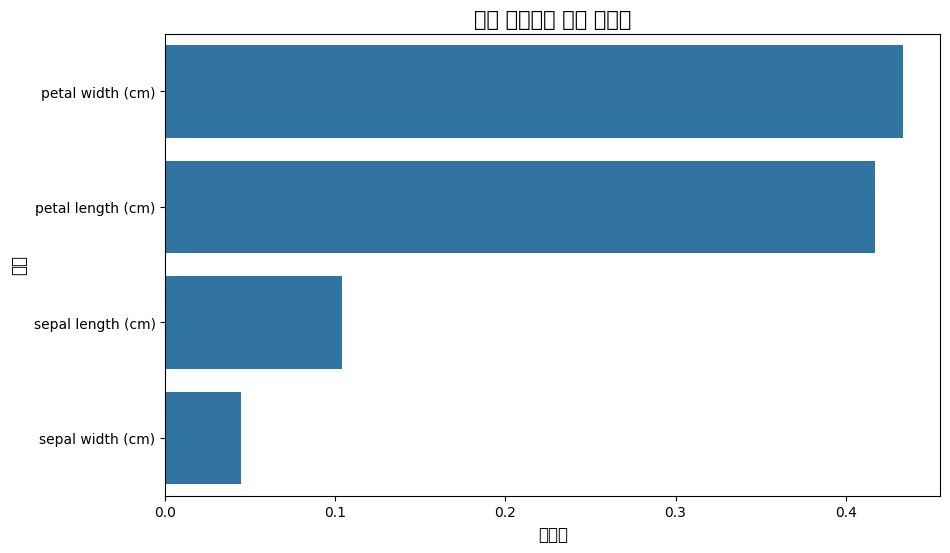


--- 랜덤 포레스트 변수 중요도 설명 ---
랜덤 포레스트의 변수 중요도는 각 특성이 트리의 불순도를 얼마나 감소시키는지를 측정하여 계산됩니다. 일반적으로, 특정 특성이 트리의 분할에 사용될 때 불순도(Gini 불순도 또는 엔트로피)를 크게 감소시킬수록 해당 특성의 중요도가 높아집니다. 랜덤 포레스트는 모든 트리에 걸쳐 이러한 불순도 감소량을 평균하여 최종 특성 중요도를 산출합니다. 이는 모델 예측에 가장 큰 영향을 미치는 특성을 파악하는 데 유용합니다.


--- OOB (Out-of-Bag) 점수 설명 ---
OOB 점수는 랜덤 포레스트 모델 학습 시 사용되지 않은(Out-of-Bag) 샘플들을 사용하여 모델의 성능을 자체적으로 검증하는 방법입니다. `oob_score=True`로 설정하면 이 점수를 얻을 수 있으며, 별도의 검증 세트 없이도 모델의 일반화 성능을 추정할 수 있습니다.

OOB 스코어: 0.9429

--- 그루 수 및 분기당 변수 수 조절 ---
랜덤 포레스트의 `n_estimators` (그루 수)는 모델의 안정성과 복잡성에 영향을 미치며, `max_features` (분기당 고려할 변수 수)는 각 트리의 다양성과 과적합 방지에 기여합니다. 이 두 파라미터를 조절하여 모델의 성능을 최적화할 수 있습니다.


In [11]:
import numpy as np
import seaborn as sns # seaborn 라이브러리 임포트 추가

# 변수 중요도 추출
feature_importances = random_forest_classifier.feature_importances_

# 중요도를 DataFrame으로 변환하여 시각화
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\n--- 변수 중요도 ---")
display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('랜덤 포레스트 특성 중요도', fontsize=15)
plt.xlabel('중요도', fontsize=12)
plt.ylabel('특성', fontsize=12)
plt.show()

print("\n--- 랜덤 포레스트 변수 중요도 설명 ---")
print("랜덤 포레스트의 변수 중요도는 각 특성이 트리의 불순도를 얼마나 감소시키는지를 측정하여 계산됩니다. 일반적으로, 특정 특성이 트리의 분할에 사용될 때 불순도(Gini 불순도 또는 엔트로피)를 크게 감소시킬수록 해당 특성의 중요도가 높아집니다. 랜덤 포레스트는 모든 트리에 걸쳐 이러한 불순도 감소량을 평균하여 최종 특성 중요도를 산출합니다. 이는 모델 예측에 가장 큰 영향을 미치는 특성을 파악하는 데 유용합니다.\n")

print("\n--- OOB (Out-of-Bag) 점수 설명 ---")
print("OOB 점수는 랜덤 포레스트 모델 학습 시 사용되지 않은(Out-of-Bag) 샘플들을 사용하여 모델의 성능을 자체적으로 검증하는 방법입니다. `oob_score=True`로 설정하면 이 점수를 얻을 수 있으며, 별도의 검증 세트 없이도 모델의 일반화 성능을 추정할 수 있습니다.\n")
print(f"OOB 스코어: {random_forest_classifier.oob_score_:.4f}")

print("\n--- 그루 수 및 분기당 변수 수 조절 ---")
print("랜덤 포레스트의 `n_estimators` (그루 수)는 모델의 안정성과 복잡성에 영향을 미치며, `max_features` (분기당 고려할 변수 수)는 각 트리의 다양성과 과적합 방지에 기여합니다. 이 두 파라미터를 조절하여 모델의 성능을 최적화할 수 있습니다.")


### **랜덤 포레스트 하이퍼파라미터 튜닝: `n_estimators`와 `max_depth`**

`n_estimators`는 랜덤 포레스트에 포함될 결정 트리의 개수를, `max_depth`는 각 개별 트리의 최대 깊이를 의미합니다. 이 두 하이퍼파라미터는 모델의 성능과 과적합/과소적합 사이의 균형을 조절하는 데 중요합니다. 다양한 조합으로 모델을 학습시키고 성능을 비교해봅시다.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# n_estimators (트리 개수) 변화에 따른 성능
print("\n--- n_estimators (트리 개수) 변화에 따른 성능 ---")
n_estimators_list = [10, 50, 100, 200, 500]
results_n_estimators = []

for n in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    oob_score = rf_model.oob_score_
    results_n_estimators.append({'n_estimators': n, 'Accuracy': accuracy, 'OOB Score': oob_score})

display(pd.DataFrame(results_n_estimators))

# max_depth (최대 깊이) 변화에 따른 성능
print("\n--- max_depth (최대 깊이) 변화에 따른 성능 ---")
max_depth_list = [2, 5, 10, None] # None은 깊이 제한 없음
results_max_depth = []

for depth in max_depth_list:
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, oob_score=True, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    oob_score = rf_model.oob_score_
    results_max_depth.append({'max_depth': depth, 'Accuracy': accuracy, 'OOB Score': oob_score})

display(pd.DataFrame(results_max_depth))

print("\n--- 하이퍼파라미터 튜닝 설명 ---")
print("`n_estimators`가 증가할수록 모델의 안정성이 높아지고 성능이 향상되는 경향이 있습니다. 하지만 일정 수준 이상에서는 성능 향상이 미미하고 계산 비용만 증가할 수 있습니다.\n")
print("`max_depth`는 개별 트리의 복잡도를 제어합니다. `max_depth`가 너무 낮으면 과소적합될 수 있고, 너무 높거나 `None`으로 설정하면 개별 트리는 과적합되지만, 랜덤 포레스트의 앙상블 특성 때문에 전체 모델은 과적합에 강한 모습을 보일 수 있습니다. 최적의 값을 찾기 위해서는 교차 검증(Cross-validation)과 그리드 서치(Grid Search) 같은 방법을 사용하는 것이 일반적입니다.")


--- n_estimators (트리 개수) 변화에 따른 성능 ---


,n_estimators,Accuracy,OOB Score
0,10,1.0,0.923810
1,50,1.0,0.942857
2,100,1.0,0.942857
3,200,1.0,0.923810
4,500,1.0,0.942857



--- max_depth (최대 깊이) 변화에 따른 성능 ---


,max_depth,Accuracy,OOB Score
0,2.0,1.0,0.933333
1,5.0,1.0,0.942857
2,10.0,1.0,0.942857
3,NaN,1.0,0.942857



--- 하이퍼파라미터 튜닝 설명 ---
`n_estimators`가 증가할수록 모델의 안정성이 높아지고 성능이 향상되는 경향이 있습니다. 하지만 일정 수준 이상에서는 성능 향상이 미미하고 계산 비용만 증가할 수 있습니다.

`max_depth`는 개별 트리의 복잡도를 제어합니다. `max_depth`가 너무 낮으면 과소적합될 수 있고, 너무 높거나 `None`으로 설정하면 개별 트리는 과적합되지만, 랜덤 포레스트의 앙상블 특성 때문에 전체 모델은 과적합에 강한 모습을 보일 수 있습니다. 최적의 값을 찾기 위해서는 교차 검증(Cross-validation)과 그리드 서치(Grid Search) 같은 방법을 사용하는 것이 일반적입니다.


## 내용 요약 정리

이 노트북은 **의사결정 트리**와 **랜덤 포레스트**의 핵심 개념을 코드를 통해 시연하고 설명했습니다.

1.  **트리 생성 및 이해**: `scikit-learn`의 `DecisionTreeClassifier`를 사용하여 Iris 데이터셋으로 기본적인 의사결정 트리를 구축하고 시각화했습니다. 지니 불순도와 같은 불순도 개념을 통해 트리가 데이터를 어떻게 분할하는지 이해했습니다.

2.  **과적합 제어**: 의사결정 트리가 깊어질수록 과적합될 수 있음을 확인하고, `max_depth`와 같은 가지치기(Pruning) 매개변수를 사용하여 트리의 복잡도를 제어하고 일반화 성능을 향상시키는 방법을 시연했습니다.

3.  **랜덤 포레스트의 원리**: 여러 개의 약한 트리를 모아 더 강력한 모델을 만드는 앙상블 기법인 `RandomForestClassifier`를 소개했습니다. 배깅(Bagging)과 무작위 특성 선택을 통해 모델의 다양성과 안정성을 확보하는 원리를 설명하고, 단일 트리와의 성능을 비교하여 앙상블 모델의 장점을 확인했습니다.

4.  **숲 해석**: 학습된 랜덤 포레스트 모델에서 `feature_importances_`를 통해 각 특성이 예측에 미치는 영향력을 파악하는 방법을 보여주었습니다. 또한, OOB(Out-of-Bag) 스코어를 통해 모델의 일반화 성능을 내부적으로 검증하는 개념을 간략히 설명했습니다.

이러한 코딩 시나리오를 통해 의사결정 트리와 랜덤 포레스트의 기본 개념부터 과적합 방지, 앙상블의 장점, 모델 해석까지의 과정을 실습적으로 이해할 수 있습니다.

### **학습 목표 05: 허깅 페이스 모델을 활용한 분류**

`scikit-learn` 외에도, 최근에는 자연어 처리(NLP) 분야에서 뛰어난 성능을 보이는 **Hugging Face Transformers** 라이브러리를 활용하여 다양한 분류 작업을 수행할 수 있습니다. 여기서는 간단한 텍스트 분류 예제를 통해 Hugging Face 모델의 사용법을 보여드립니다.

In [13]:
# Hugging Face Transformers 라이브러리 설치
!pip install transformers

In [14]:
from transformers import pipeline

# 감성 분석(Sentiment Analysis)을 위한 파이프라인 로드
# 이는 텍스트가 긍정적인지 부정적인지 분류하는 이진 분류 작업입니다.
sentiment_pipeline = pipeline("sentiment-analysis")

print("Hugging Face 감성 분석 모델 로드 완료!")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Hugging Face 감성 분석 모델 로드 완료!


In [15]:
# 예제 텍스트로 감성 분석 수행
texts = [
    "This movie is absolutely fantastic and I loved every minute of it!",
    "The food was terrible, I would not recommend it.",
    "I am feeling neutral about this situation."
]

print("\n--- 텍스트 감성 분석 결과 ---")
for text in texts:
    result = sentiment_pipeline(text)
    print(f"텍스트: '{text}'\n결과: {result[0]['label']} (점수: {result[0]['score']:.4f})\n")

print("\n--- Hugging Face 모델 설명 ---")
print("Hugging Face 라이브러리는 BERT, GPT, T5와 같은 다양한 사전 학습된 트랜스포머 모델을 제공합니다. 이 모델들은 대규모 텍스트 데이터셋으로 미리 학습되어 있어, 전이 학습(Transfer Learning)을 통해 적은 데이터로도 특정 분류 작업에서 높은 성능을 달성할 수 있습니다. 위 예제에서는 `sentiment-analysis` 파이프라인을 사용하여 텍스트의 긍정/부정을 분류했습니다.")


--- 텍스트 감성 분석 결과 ---
텍스트: 'This movie is absolutely fantastic and I loved every minute of it!'
결과: POSITIVE (점수: 0.9999)

텍스트: 'The food was terrible, I would not recommend it.'
결과: NEGATIVE (점수: 0.9977)

텍스트: 'I am feeling neutral about this situation.'
결과: NEGATIVE (점수: 0.9970)


--- Hugging Face 모델 설명 ---
Hugging Face 라이브러리는 BERT, GPT, T5와 같은 다양한 사전 학습된 트랜스포머 모델을 제공합니다. 이 모델들은 대규모 텍스트 데이터셋으로 미리 학습되어 있어, 전이 학습(Transfer Learning)을 통해 적은 데이터로도 특정 분류 작업에서 높은 성능을 달성할 수 있습니다. 위 예제에서는 `sentiment-analysis` 파이프라인을 사용하여 텍스트의 긍정/부정을 분류했습니다.


## Resources

### 감성 분석 기법 및 결정 이유

이 노트북에서 감성 분석을 위해 **Hugging Face Transformers 라이브러리의 `pipeline` 추상화**를 사용했습니다. 구체적으로는 `sentiment-analysis` 작업을 위해 사전 학습된 모델이 자동으로 로드되어 사용되었습니다 (내부적으로 `distilbert-base-uncased-finetuned-sst-2-english` 모델이 활용됨).

**이 기법을 선택한 이유는 다음과 같습니다:**

1.  **최첨단 성능**: Hugging Face Transformers는 자연어 처리(NLP) 분야에서 BERT, GPT 등과 같은 최신 및 최첨단 딥러닝 모델들을 제공합니다. 이 모델들은 방대한 텍스트 데이터셋으로 미리 학습되어 있어, 복잡한 텍스트 분류 작업에서 뛰어난 성능을 발휘합니다.
2.  **전이 학습(Transfer Learning)의 이점**: 사전 학습된 모델들은 이미 언어의 복잡한 패턴과 의미를 이해하고 있습니다. 따라서 특정 작업(예: 감성 분석)에 대해 추가 학습(파인튜닝)할 때, 적은 양의 데이터로도 높은 정확도를 달성할 수 있습니다. 이는 처음부터 모델을 구축하고 학습하는 것보다 훨씬 효율적입니다.
3.  **간편한 사용법**: Hugging Face의 `pipeline`은 복잡한 모델 아키텍처나 전처리 과정을 직접 다루지 않고도 특정 NLP 작업을 쉽게 수행할 수 있도록 추상화된 인터페이스를 제공합니다. 이는 모델 로딩, 토큰화, 예측까지의 전 과정을 단 몇 줄의 코드로 처리할 수 있게 하여 개발 효율성을 높여줍니다.
4.  **다양한 활용성**: 이 접근 방식은 감성 분석뿐만 아니라 텍스트 요약, 질문 응답, 명명된 개체 인식 등 다양한 NLP 태스크에 유연하게 적용될 수 있어, 범용적인 솔루션으로 활용하기에 적합합니다.

결론적으로, Hugging Face 모델은 NLP 작업의 복잡성을 줄이면서도 강력한 성능을 제공하기 때문에, 이 학습 목표에서 딥러닝 기반의 텍스트 분류를 시연하는 데 가장 적합한 선택이었습니다.

### 랜덤 포레스트와 감성 분석 모델 (Hugging Face) 비교

이 노트북에서 다룬 **랜덤 포레스트**와 **Hugging Face 기반 감성 분석 모델**은 각기 다른 장단점과 적용 분야를 가집니다.

#### **랜덤 포레스트 (Random Forest)**

**장점:**

*   **높은 정확도**: 여러 의사결정 트리의 앙상블을 통해 단일 트리에 비해 높은 예측 정확도를 달성합니다.
*   **과적합 감소**: 배깅(Bagging)과 무작위 특성 선택을 통해 과적합을 효과적으로 줄여 일반화 성능이 우수합니다.
*   **다차원 데이터 처리**: 고차원 데이터셋에서도 잘 작동합니다.
*   **결측값 처리**: 데이터 전처리 단계에서 결측값을 대체하거나 제거하는 과정 없이도 어느 정도 처리할 수 있습니다.
*   **특성 중요도 제공**: 모델 예측에 각 특성이 얼마나 기여하는지(특성 중요도)를 정량적으로 파악할 수 있어 모델 해석에 도움을 줍니다.
*   **이상치 및 노이즈에 강인함**: 앙상블 특성 덕분에 데이터의 이상치나 노이즈에 비교적 강합니다.

**단점:**

*   **낮은 해석 가능성**: 단일 의사결정 트리에 비해 '블랙박스' 모델에 가까워 예측 과정을 시각적으로 이해하기 어렵습니다.
*   **계산 비용**: 많은 수의 트리를 구축하고 결합해야 하므로 훈련 시간이 길고 계산 자원을 더 많이 소모합니다.
*   **실시간 예측 지연**: 대규모 데이터셋에 대해 실시간 예측 시 여러 트리를 거쳐야 하므로 지연이 발생할 수 있습니다.
*   **하이퍼파라미터 튜닝**: `n_estimators`, `max_depth`, `max_features` 등 여러 하이퍼파라미터 튜닝이 필요합니다.

#### **감성 분석 모델 (Hugging Face Transformers 기반)**

**장점:**

*   **최첨단 성능**: BERT, GPT와 같은 대규모 사전 학습 모델을 기반으로 자연어 처리(NLP) 작업에서 매우 높은 정확도를 보여줍니다.
*   **전이 학습(Transfer Learning)**: 방대한 텍스트 데이터로 사전 학습된 모델을 특정 작업에 맞춰 미세 조정(Fine-tuning)함으로써, 적은 데이터로도 우수한 성능을 달성할 수 있습니다.
*   **복잡한 언어 패턴 이해**: 텍스트의 복잡한 문맥과 의미론적 관계를 깊이 있게 파악합니다.
*   **간편한 사용법 (Pipeline)**: Hugging Face의 `pipeline` 추상화를 통해 복잡한 딥러닝 모델 아키텍처나 전처리 과정을 직접 다루지 않고도 쉽게 사용할 수 있습니다.
*   **다양한 NLP 작업 적용**: 감성 분석 외에도 텍스트 요약, 질의응답, 번역 등 광범위한 NLP 태스크에 유연하게 적용 가능합니다.

**단점:**

*   **높은 계산 자원 요구량**: 모델 훈련(특히 사전 학습) 및 미세 조정에 막대한 계산 자원(GPU/TPU)이 필요합니다.
*   **낮은 해석 가능성**: 딥러닝 모델의 특성상 내부 작동 원리를 이해하기 어려워 예측 결과에 대한 설명이 어렵습니다.
*   **모델 크기 및 지연**: 모델의 크기가 매우 커서 배포 시 많은 메모리를 사용하고 예측 시간이 길어질 수 있습니다.
*   **사전 학습 데이터 의존성**: 모델의 성능이 사전 학습 데이터의 품질과 도메인 특성에 크게 의존합니다. 특정 도메인에 대한 편향이 있을 수 있습니다.

**결론적으로**, **랜덤 포레스트**는 정형/반정형 데이터 분류에 강력하고 해석 가능성과 효율성 사이의 좋은 균형을 제공하는 반면, **Hugging Face 감성 분석 모델**은 비정형 텍스트 데이터의 복잡한 패턴을 이해하고 분류하는 데 탁월하며 최첨단 성능을 제공합니다.

### 앙상블 학습(Ensemble Learning)의 중요성과 활용

**앙상블 학습**은 여러 개의 개별 모델(weak learner)을 결합하여 하나의 강력한 예측 모델(strong learner)을 만드는 기법입니다. 단일 모델의 한계를 극복하고 예측 성능을 향상시키는 데 목표를 둡니다. 이 노트북에서 다룬 **랜덤 포레스트**가 바로 앙상블 학습의 대표적인 예시입니다.

**앙상블 학습의 핵심 내용:**

1.  **다양성(Diversity)**: 개별 모델들이 서로 다른 방식으로 오류를 범해야 앙상블 효과가 극대화됩니다. 이를 위해 데이터를 다르게 샘플링하거나(예: 배깅), 특성을 다르게 선택하거나(예: 랜덤 포레스트), 모델 자체를 다르게 구성(예: 스태킹)합니다.
2.  **모델 결합**: 개별 모델의 예측을 결합하는 방법에는 여러 가지가 있습니다.
    *   **투표(Voting)**: 분류 문제에서 다수결 투표를 통해 최종 클래스를 결정합니다.
    *   **평균(Averaging)**: 회귀 문제에서 개별 예측값의 평균을 사용합니다.
    *   **가중치 부여(Weighted Averaging/Voting)**: 각 모델의 성능에 따라 가중치를 다르게 부여하여 결합합니다.

**주요 앙상블 기법:**

*   **배깅(Bagging)**: Bootstrap Aggregating의 약자로, 원본 데이터셋에서 여러 개의 서브셋을 무작위 복원 추출(Bootstrap Sampling)하여 각 서브셋으로 개별 모델을 학습시킵니다. 학습된 모델들의 예측을 평균하거나 투표하여 최종 예측을 만듭니다. **랜덤 포레스트**는 배깅 기법을 의사결정 트리에 적용하고, 추가적으로 노드 분할 시 특성 무작위 선택을 도입한 모델입니다.
*   **부스팅(Boosting)**: 약한 학습기(weak learner)들을 순차적으로 학습시키면서 이전 학습기가 잘못 분류한 샘플에 더 큰 가중치를 부여하여 다음 학습기가 집중하도록 합니다. 대표적으로 AdaBoost, Gradient Boosting (XGBoost, LightGBM, CatBoost) 등이 있습니다.
*   **스태킹(Stacking)**: 서로 다른 종류의 모델들을 결합하는 방법입니다. 1단계 모델(base models)의 예측값을 새로운 특성으로 사용하여 2단계 모델(meta model)을 학습시킵니다.

**앙상블 학습은 어떤 분야에 쓰이나요?**

앙상블 학습은 그 뛰어난 예측 성능 덕분에 기계 학습의 거의 모든 분야에서 광범위하게 활용됩니다:

*   **이미지 분류 및 객체 탐지**: 여러 CNN 모델의 앙상블이 더 정확한 결과를 도출합니다.
*   **자연어 처리 (NLP)**: 텍스트 분류, 감성 분석 등에서 다양한 모델의 조합이 성능을 높입니다.
*   **금융 분야**: 주가 예측, 신용 점수 평가, 사기 탐지 등 높은 정확도가 요구되는 분야에서 주로 사용됩니다.
*   **의료 진단**: 질병 진단, 약물 반응 예측 등에서 모델의 안정성과 신뢰도를 높입니다.
*   **추천 시스템**: 사용자의 선호도를 예측하는 데 앙상블 모델이 활용됩니다.
*   **경쟁 플랫폼(Kaggle 등)**: 데이터 과학 경연 대회에서 우승자들이 가장 많이 사용하는 기법 중 하나입니다.

**요약하자면**, 앙상블 학습은 단일 모델의 약점을 보완하고 강력한 일반화 성능을 얻기 위한 강력한 도구이며, 특히 **랜덤 포레스트**는 이러한 앙상블의 장점을 잘 보여주는 모델입니다. `랜덤 포레스트`에 대한 더 자세한 내용은 위 "**학습 목표 03: 왜 숲인지 안다**" 섹션에서 확인하실 수 있습니다.

### 랜덤 포레스트와 앙상블 학습의 주요 차이점

랜덤 포레스트는 앙상블 학습의 한 종류이지만, 앙상블 학습이라는 더 큰 범주 내에서 특정 기법과 특징을 가집니다. 다음 표는 이 둘의 주요 차이점을 정리한 것입니다.

| 특징/분류 | 앙상블 학습 (Ensemble Learning) | 랜덤 포레스트 (Random Forest) |
|---|---|---|
| **정의** | 여러 개의 개별 학습 모델을 결합하여 하나의 더 강력한 예측 모델을 만드는 기법의 총칭. | 배깅(Bagging) 기법을 기반으로 하는 의사결정 트리 앙상블 모델. 각 트리는 무작위 샘플링된 데이터와 무작위 특성 선택을 통해 학습됨. |
| **범주** | 광범위한 기계 학습 패러다임. | 앙상블 학습의 한 특정 알고리즘. |
| **구성 모델** | 모든 종류의 모델(예: 의사결정 트리, 신경망, SVM 등)을 포함할 수 있음. | **오직 의사결정 트리**만을 개별 모델로 사용함. |
| **주요 기법** | 배깅(Bagging), 부스팅(Boosting), 스태킹(Stacking) 등 다양한 기법이 존재. | **배깅(Bagging)**이 핵심이며, 여기에 **무작위 특성 선택**이 추가됨. |
| **목표** | 단일 모델의 한계를 극복하고 예측 성능, 안정성, 일반화 능력 향상. | 단일 의사결정 트리의 과적합 문제 해결 및 성능 향상. |
| **다양성 확보** | 데이터를 샘플링하거나(배깅), 모델을 순차적으로 학습시키거나(부스팅), 다른 종류의 모델을 사용(스태킹)하는 등 다양한 방식. | 1. **부트스트랩 샘플링**: 각 트리가 훈련 데이터의 무작위 복원 샘플로 학습.
2. **무작위 특성 선택**: 노드 분할 시 모든 특성 대신 무작위로 선택된 일부 특성만 고려. |
| **복잡도** | 결합하는 모델의 종류와 수에 따라 다양. | 일반적으로 `n_estimators`(트리 수)와 `max_depth`(트리 깊이)에 따라 결정. |
| **예시** | 랜덤 포레스트, Gradient Boosting Machines (GBM), XGBoost, AdaBoost 등. | 랜덤 포레스트 자체가 대표적인 예시. |

**요약:**
앙상블 학습은 여러 모델을 조합하여 성능을 높이는 **전략**을 의미하며, 랜덤 포레스트는 그 전략 중 하나인 **배깅**을 활용하여 **의사결정 트리**들을 모아 만든 특정 **알고리즘**입니다.

### **총 내용 요약 정리**

이 노트북은 머신러닝의 핵심 분류 모델인 **의사결정 트리**, **랜덤 포레스트**의 이론과 실제 구현을 다루었으며, 더 나아가 현대 인공지능 분야에서 널리 사용되는 **Hugging Face 모델**을 활용한 분류의 기초도 소개했습니다.

1.  **의사결정 트리 (Gini 불순도 및 정보 이득)**: 트리의 기본 구조, **Gini 불순도 계산 원리** 및 **엔트로피(정보 이득)**를 기반으로 한 데이터 분할 원리를 이해하고, 시각화를 통해 트리의 작동 방식을 이해했습니다.
2.  **과적합 제어**: `max_depth`와 같은 가지치기 기법을 통해 의사결정 트리의 복잡도를 제어하고 과적합을 방지하는 방법을 실습했습니다.
3.  **랜덤 포레스트**: 단일 트리의 한계를 극복하기 위한 앙상블 기법인 랜덤 포레스트의 원리(배깅, 무작위 특성 선택)를 학습하고, 단일 트리 대비 향상된 성능을 확인했습니다.
4.  **숲 해석 및 하이퍼파라미터 튜닝**: **변수 중요도(Feature Importance)가 트리의 불순도 감소량 평균을 기반으로 어떻게 계산되는지**를 파악하고, OOB 스코어 개념을 이해했습니다. `n_estimators`와 `max_depth` 하이퍼파라미터 튜닝의 중요성을 알아보았습니다.
5.  **Hugging Face 모델 활용**: `transformers` 라이브러리를 사용하여 사전 학습된 텍스트 분류(감성 분석) 모델을 로드하고 활용하는 방법을 실습했습니다. 이는 `scikit-learn` 기반의 전통적인 모델들과는 다른 접근 방식이지만, 복잡한 데이터(특히 텍스트)에 대한 분류 작업에서 강력한 성능을 발휘합니다.

이 과정을 통해 다양한 분류 모델의 작동 원리를 이해하고, 각 모델의 장단점을 파악하며, 실제 데이터에 적용할 수 있는 실용적인 지식을 습득했습니다.